# Gravity removal: Euler angles

This notebook removes the gravity component using the orientation obtained from either the [complementary filter with Euler angles](../3-orientation/1-complementaryFilterEuler.ipynb) or the [Mahony filter with Quaternions](../3-orientation/2-mahonyQuaternion.ipynb). Multiple analyses are performed to address removal performance. For the Mahony filter, there are not significant differences between using Euler angles and quaternions for orientation *after* the filter has run (i.e. Euler angles and gimbal lock are avoided in the internal representation of orientation). However, the implemented Quaternion class is slower (by roughly two orders of magnitude) than numpy operations that use C code under the hood. Because of this reason, the Euler angle representation is preferred for gravity removal in this notebook.

**Important**: gravity removal is done on the *body frame* instead of the world frame. This is important for downstream acceleration bias correction, which is performed on the body frame.

## Setup

In [13]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    Quaternion,
)
from signal_utils.IMUStationaryDetector import (
    InstantaneousIMUStationaryDetector,
    WindowedIMUStationaryDetector,
)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, signal
import math
import os

SAMPLING_FREQUENCY = 30  # Hz
DIRECTORY_IDX = 22

# Mahony filter
# """
path = "../3-orientation/output/mahony/"
gridSearchDirectories = [
    f"{path}{dir}" for dir in os.listdir(path) if os.path.isdir(os.path.join(path, dir))
]  # Listing paths directly is unfeasible
gridSearchDirectories.sort()  # Ensure deterministic order (important for DIRECTORY_IDX)
stationaryCaptures = [
    "pos-x-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-x-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pos-y-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-y-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pos-z-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-z-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
]
simpleRotationsCaptures = [
    "rot-x-hw-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "rot-y-hw-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "rot-z-hw-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
]
realExerciseCaptures = [
    "dips-1-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "dips-2-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "dips-3-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pull-ups-1-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pull-ups-2-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "pull-ups-3-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "90-deg-push-ups-1-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
    "90-deg-push-ups-2-calib-affine-sixf-tilted-a-filt-box5-or-mahony.csv",
]
# """

# Complementary filter
"""
gridSearchDirectories = [
    "../3-orientation/output/ast=0.750-amv=0.950",
    "../3-orientation/output/ast=0.750-amv=0.975",
    "../3-orientation/output/ast=0.750-amv=0.990",
    "../3-orientation/output/ast=0.800-amv=0.950",
    "../3-orientation/output/ast=0.800-amv=0.975",
    "../3-orientation/output/ast=0.800-amv=0.990",
    "../3-orientation/output/ast=0.850-amv=0.950",
    "../3-orientation/output/ast=0.850-amv=0.975",
    "../3-orientation/output/ast=0.850-amv=0.990",
    "../3-orientation/output/ast=0.900-amv=0.950",
    "../3-orientation/output/ast=0.900-amv=0.975",
    "../3-orientation/output/ast=0.900-amv=0.990",
    "../3-orientation/output/ast=0.950-amv=0.950",
    "../3-orientation/output/ast=0.950-amv=0.975",
    "../3-orientation/output/ast=0.950-amv=0.990",
]
stationaryCaptures = [
    "pos-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
]
simpleRotationsCaptures = [
    "rot-x-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "rot-y-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "rot-z-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
]
realExerciseCaptures = [
    "dips-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "dips-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "dips-3-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pull-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pull-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pull-ups-3-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
]
"""


def mergeDirectoryWithCaptures(directory: str, captures: list) -> list:
    result = []
    for capture in captures:
        result.append(f"{directory}/{capture}")
    return result


# stationaryDetector = InstantaneousIMUStationaryDetector()
stationaryDetector = WindowedIMUStationaryDetector(samplingFrequency=SAMPLING_FREQUENCY)
stationaryDetector.computeTolerances(
    mergeDirectoryWithCaptures(gridSearchDirectories[DIRECTORY_IDX], stationaryCaptures)
)
reader = IMUSampleReader()
writer = IMUSampleWriter()

Acceleration norms:
	Median = 9.814315 m/s²
	MAD = 0.051965 (tol = 0.259826) m/s²
	Stationary interval = [9.554489, 10.074141] m/s²
Gyroscope norms:
	Median = 0.091010 deg/s
	MAD = 0.013689 (tol = 0.684447) deg/s
	Stationary interval = [-0.593437, 0.775457] deg/s



## Computation

In [14]:
G = 9.80665
G_VECTOR_WORLD = np.array([0, 0, -G])


def subtractGravityEuler(fB, angles):
    return fB + getGravityInBodyFrameEuler(angles)


def subtractGravityQuaternion(fB, s, v):
    aB = np.zeros_like(fB)
    for i in range(fB.shape[0]):
        aB[i] = fB[i] + Quaternion(s=s[i], v=v[i]).conjugate().rotate(G_VECTOR_WORLD)
    return aB


def getWorldToBodyTransformationMatrices(rolls, pitches, yaws):
    n = len(rolls)

    rollsRad = np.radians(rolls)
    pitchesRad = np.radians(pitches)
    yawsRad = np.radians(yaws)

    cosRolls = np.cos(rollsRad)
    sinRolls = np.sin(rollsRad)
    cosPitches = np.cos(pitchesRad)
    sinPitches = np.sin(pitchesRad)
    cosYaws = np.cos(yawsRad)
    sinYaws = np.sin(yawsRad)

    Cwbx = np.zeros((n, 3, 3))
    Cwbx[:, 0, 0] = 1
    Cwbx[:, 1, 1] = cosRolls
    Cwbx[:, 1, 2] = sinRolls
    Cwbx[:, 2, 1] = -sinRolls
    Cwbx[:, 2, 2] = cosRolls

    Cwby = np.zeros((n, 3, 3))
    Cwby[:, 0, 0] = cosPitches
    Cwby[:, 0, 2] = -sinPitches
    Cwby[:, 1, 1] = 1
    Cwby[:, 2, 0] = sinPitches
    Cwby[:, 2, 2] = cosPitches

    Cwbz = np.zeros((n, 3, 3))
    Cwbz[:, 0, 0] = cosYaws
    Cwbz[:, 0, 1] = sinYaws
    Cwbz[:, 1, 0] = -sinYaws
    Cwbz[:, 1, 1] = cosYaws
    Cwbz[:, 2, 2] = 1

    return Cwbx @ Cwby @ Cwbz


def getGravityInBodyFrameEuler(angles):
    gB = np.zeros((angles.shape[0], 3))
    angleRad = np.radians(angles)
    gB[:, 0] = G * np.sin(angleRad[:, 1])
    gB[:, 1] = -G * np.cos(angleRad[:, 1]) * np.sin(angleRad[:, 0])
    gB[:, 2] = -G * np.cos(angleRad[:, 1]) * np.cos(angleRad[:, 0])
    return gB

In [15]:
checkGravityClosenessEuler = lambda a, angles: np.testing.assert_allclose(
    getWorldToBodyTransformationMatrices(angles[:, 0], angles[:, 1], angles[:, 2])
    @ G_VECTOR_WORLD,
    getGravityInBodyFrameEuler(angles),
)
checkGravitySubstractionEuler = lambda a, angles: np.testing.assert_allclose(
    subtractGravityEuler(a, angles),
    np.zeros((a.shape[0], 3)),
    atol=1e-7,
)

a = np.array([[G, 0.0, 0.0]])
angles = np.array([[0.0, -90.0, 0.0]])
checkGravityClosenessEuler(a, angles)
checkGravitySubstractionEuler(a, angles)

a = np.array([[0.0, G, 0.0]])
angles = np.array([[90.0, 0.0, 0.0]])
checkGravityClosenessEuler(a, angles)
checkGravitySubstractionEuler(a, angles)

a = np.array([[0.0, 0.0, G]])
angles = np.array([[0.0, 0.0, 0.0]])
checkGravityClosenessEuler(a, angles)
checkGravitySubstractionEuler(a, angles)

a = np.array([[G / math.sqrt(2), 0.0, G / math.sqrt(2)]])
angles = np.array([[0.0, -45.0, 0.0]])
checkGravityClosenessEuler(a, angles)
checkGravitySubstractionEuler(a, angles)

a = np.array([[0.0, G / math.sqrt(2), G / math.sqrt(2)]])
angles = np.array([[45.0, 0.0, 0.0]])
checkGravityClosenessEuler(a, angles)
checkGravitySubstractionEuler(a, angles)

fB = np.array([[G, 0.0, 0.0]])
s = np.array([0.5])
v = np.array([[0.5, 0.5, 0.5]])
eulerAngles = np.array([Quaternion(s[0], v[0]).toEulerAngles()])
np.testing.assert_allclose(
    subtractGravityEuler(fB, eulerAngles),
    subtractGravityQuaternion(fB, s, v),
    atol=1e-6,
)

fB = np.array([[G, 0.0, 0.0]])
eulerAngles = np.array([[90.0, 0.0, 0.0]])
q = Quaternion.fromEulerAngles(eulerAngles[0, 0], eulerAngles[0, 1], eulerAngles[0, 2])
np.testing.assert_allclose(
    subtractGravityEuler(fB, eulerAngles),
    subtractGravityQuaternion(
        fB,
        np.array([q.s]),
        np.asarray([q.v]),
    ),
    atol=1e-6,
)

## Histograms for one parameters tuple

In [16]:
def plotGravitySubstractionHistograms(captures):
    cols = 3
    rows = (len(captures) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(5 * cols, 5 * rows))
    fig.suptitle("Gravity-free acceleration norm histograms")

    residualsMemo = {}
    areStationaryMemo = {}

    # Cache residuals and stationary flags and compute 97.5th percentile
    residuals = []
    for capture in captures:
        readValues = reader.read(capture)
        fB = readValues[1]
        w = readValues[2]
        eulerAngles = readValues[3]

        aB = subtractGravityEuler(fB, eulerAngles)
        residualsMemo[capture] = np.linalg.norm(aB, axis=1)  # type: ignore
        areStationaryMemo[capture] = stationaryDetector.areStationarySamples(fB, w)
        residuals.append((residualsMemo[capture]))
    globalP975 = np.percentile(np.concatenate(residuals), 97.5)

    for k, capture in enumerate(captures):
        i = k // cols
        j = k % cols

        stationaryResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if isStationary
        ]
        movingResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if not isStationary
        ]

        plotResidualsHistograms(
            axes[i, j],
            stationaryResiduals,
            movingResiduals,
            0,
            globalP975,
            capture.split("/")[-1],
        )

    # Remove any unused subplots
    for k in range(len(captures), rows * cols):
        fig.delaxes(axes[k // cols, k % cols])

    plt.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


def plotResidualsHistograms(
    axis, stationaryResiduals, movingResiduals, minVal, maxVal, title
):

    axis.set_title(title, fontsize=8)
    axis.set_xlabel("Residual (m/s^2)")
    axis.set_xlim(minVal, maxVal)
    axis.set_ylabel("Frequency")

    stationaryN = len(stationaryResiduals)
    stationaryMean = np.mean(stationaryResiduals)
    stationaryStd = np.std(stationaryResiduals)
    if stationaryN > 0:

        axis.hist(
            stationaryResiduals, bins=20, color="blue", alpha=0.6, label="Stationary"
        )
        axis.axvline(
            stationaryMean,
            color="blue",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(stationary) = {stationaryMean:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"std(stationary) = {stationaryStd:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"n(stationary) = {stationaryN}",
        )

    movingN = len(movingResiduals)
    movingMean = np.mean(movingResiduals)
    movingStd = np.std(movingResiduals)
    if movingN > 0:
        axis.hist(movingResiduals, bins=20, color="red", alpha=0.6, label="Moving")
        axis.axvline(
            movingMean,
            color="red",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(moving) = {movingMean:.3f}",
        )
        axis.plot([], [], linestyle="", label=f"std(moving) = {movingStd:.3f}")
        axis.plot([], [], linestyle="", label=f"n(moving) = {movingN}")

        if stationaryN > 0:
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean diff = {movingMean - stationaryMean:.3f}",
            )
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean ratio = {movingMean / stationaryMean:.3f}",
            )

    axis.legend()
    axis.grid()

## Sanity check: stationary

When the device is stationary, the norm of the resulting acceleration vector should resemble a normal distribution with a mean close to 0 and variance due to various error sources (drift, noise, temperature, ...). This is consistent with what has been seen in the [analysis](../1-calibration/1-analysis.ipynb) of sensor data to calibrate the device. Notice that some symmetry may be lost since the norm is always non-negative. 

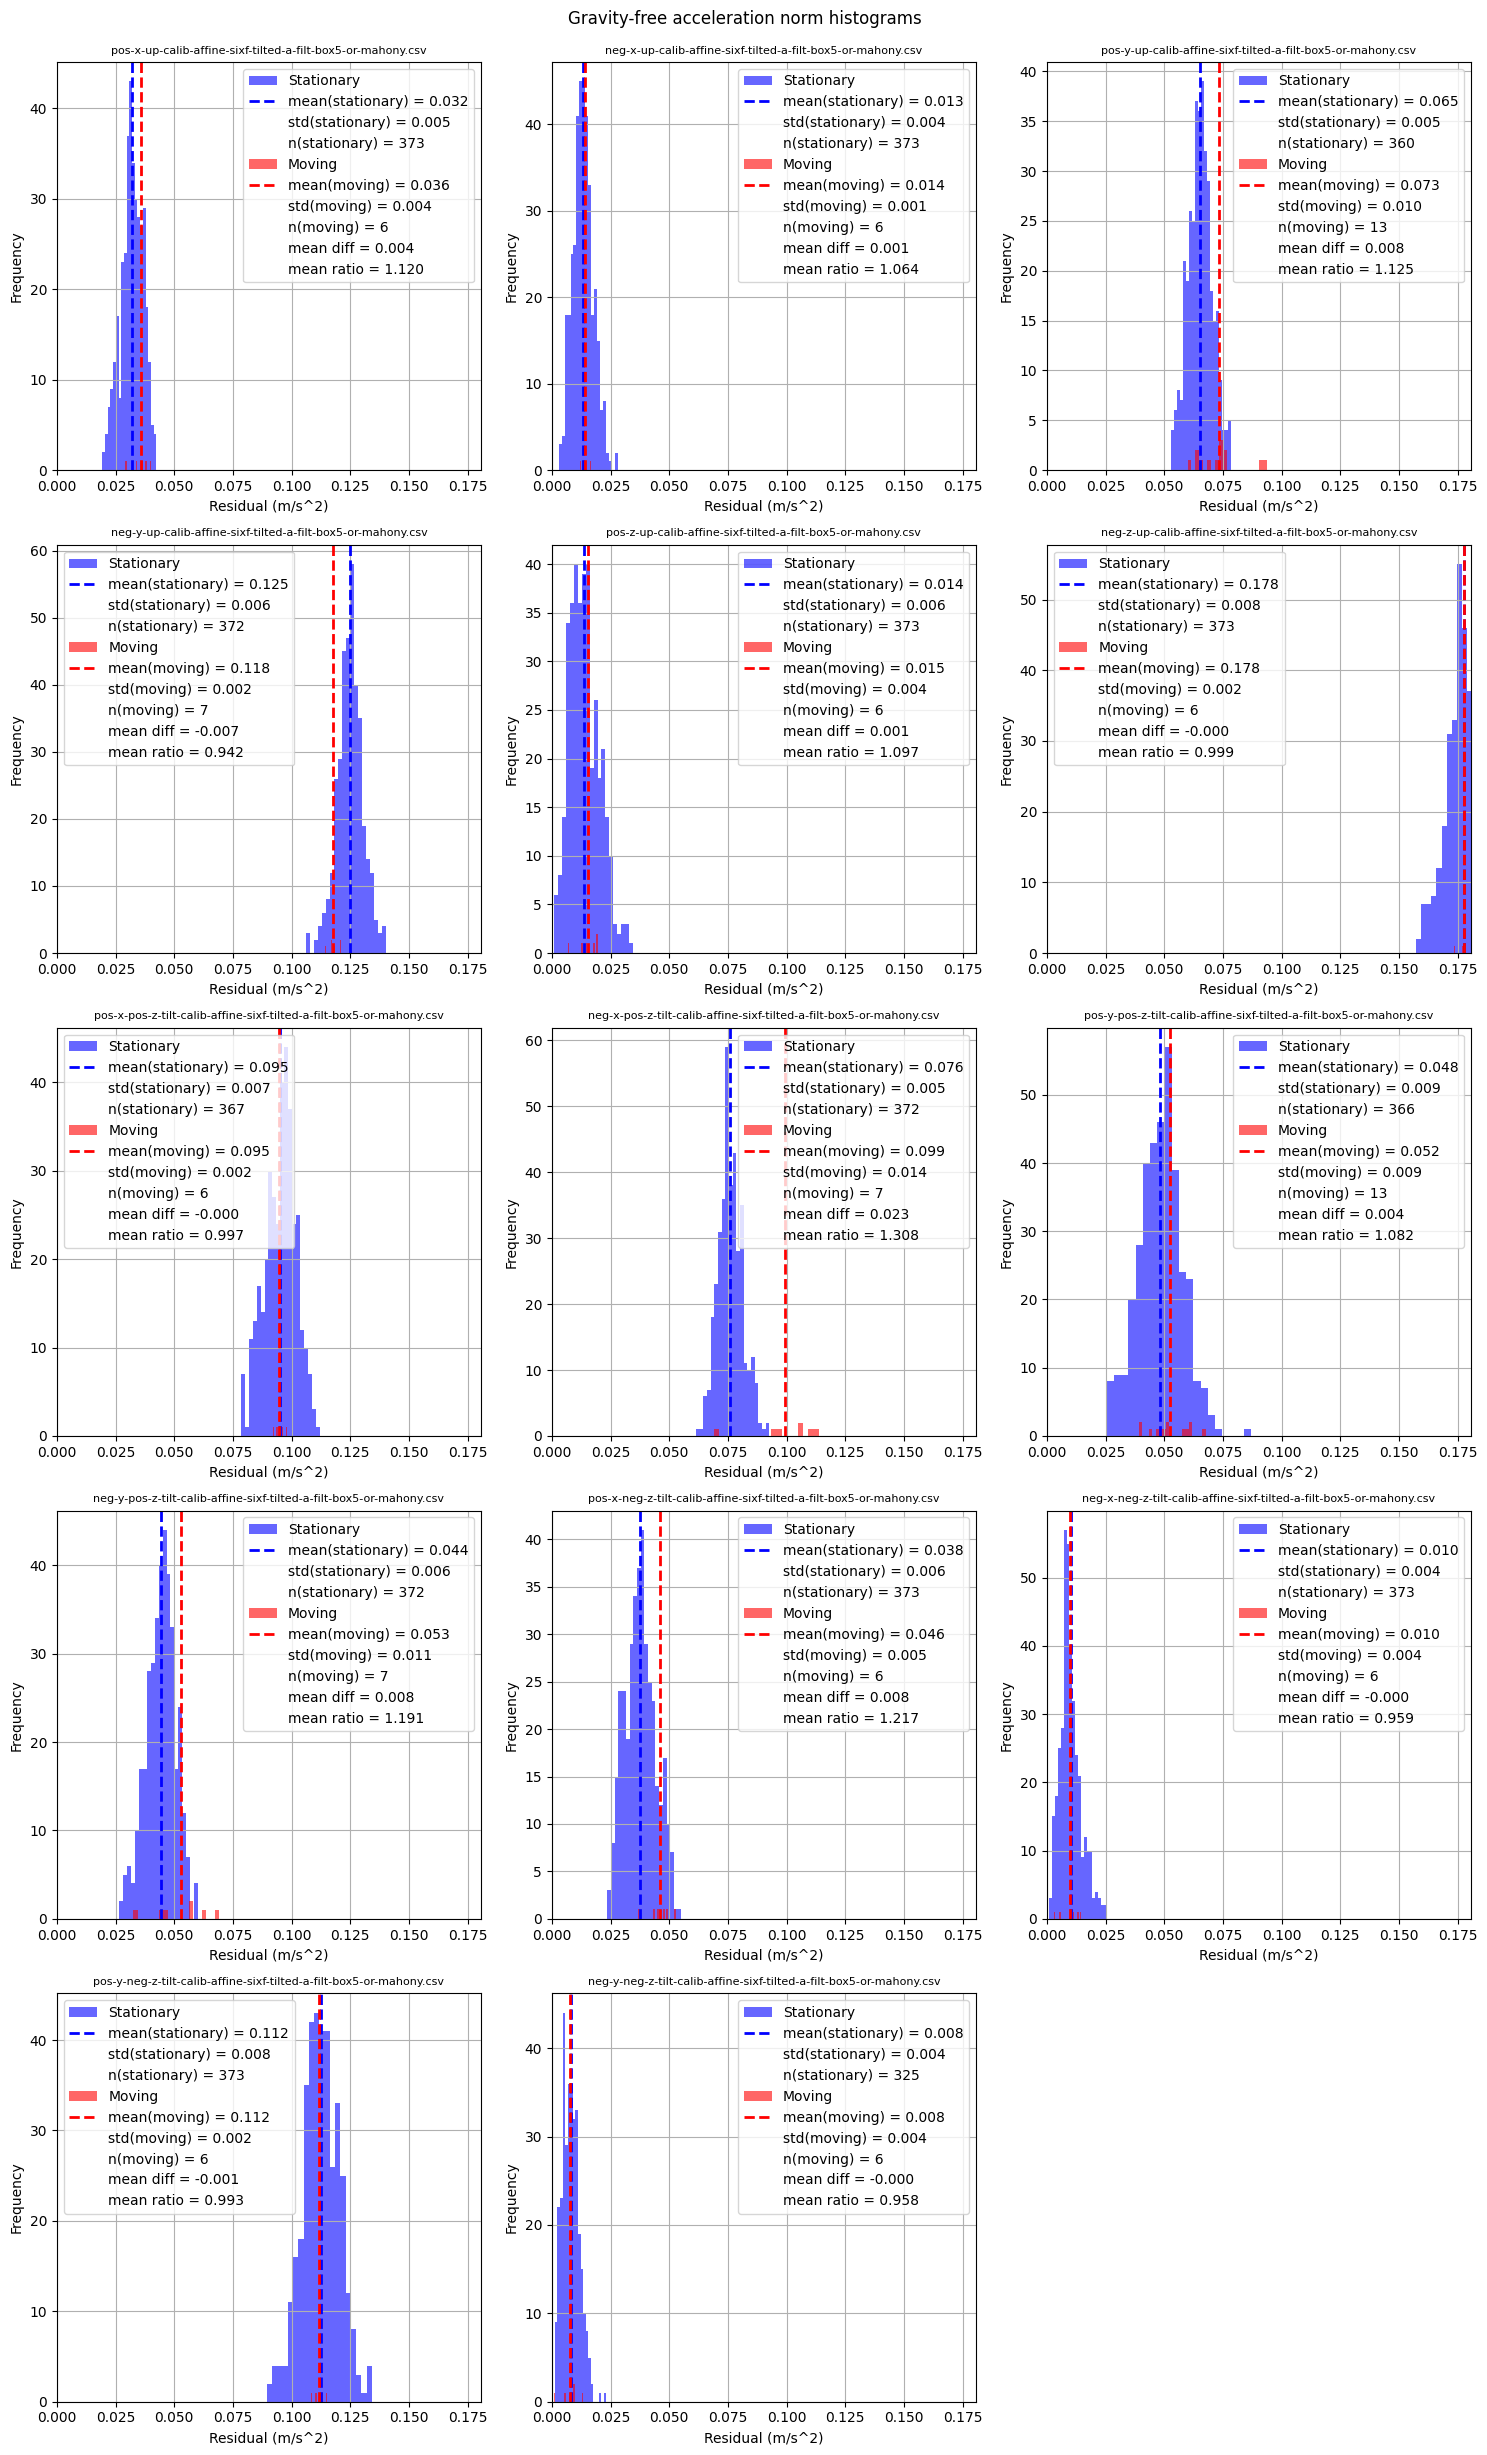

In [17]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(gridSearchDirectories[DIRECTORY_IDX], stationaryCaptures)
)

## Simple rotations

As stated in the [protocol](../0-capture/simple-rotations/dataCapture.ipynb) for the capture of simple rotations, the device is rotated around one axis at a time, interleaving brief pauses. When the device is stationary, it should resemble what was seen in the previous section. When it's moving, it should produce another approximately normal distribution to the right of the stationary distribution, but with relatively low mean since movements were performed in a controlled manner.


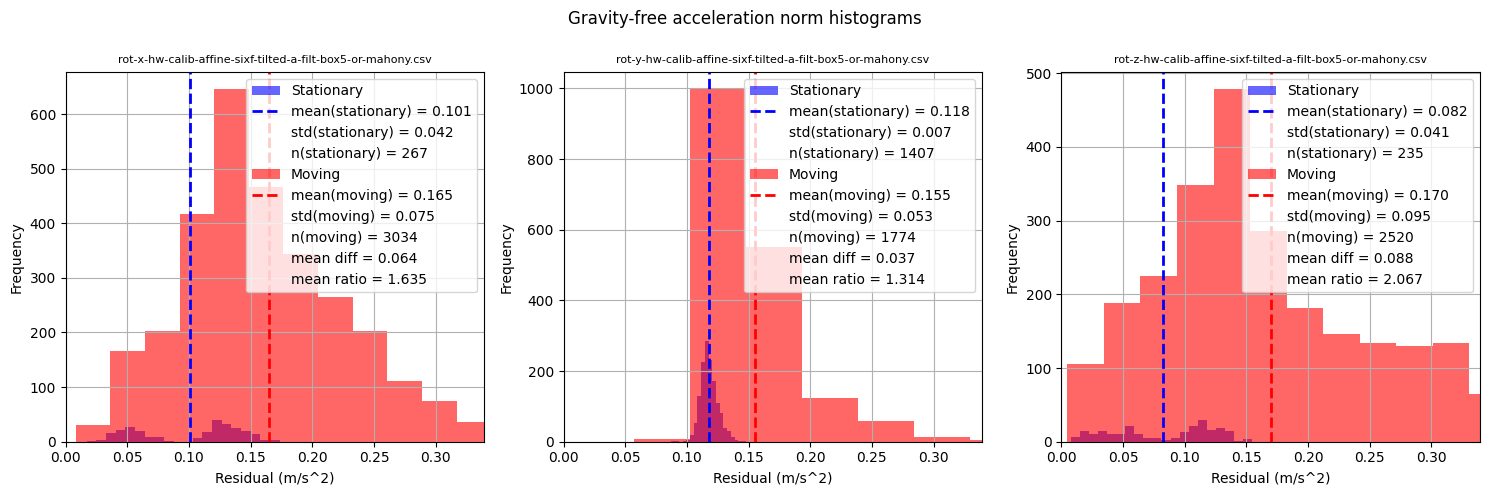

In [18]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(
        gridSearchDirectories[DIRECTORY_IDX], simpleRotationsCaptures
    )
)

## Real exercises

Real exercises are more complex, since the device may be rotate around multiple axes at the same time, change position, or move fast. 

Finding a suitable pair of parameter values for the chosen filter is needed. A set of values from a grid search is chosen to:
* Minimize the global mean of stationary acceleration norms: brief stationary intervals should show similar values to those of calibration captures.
* Maximize the difference between the average means of the stationary and moving acceleration norms: to achieve statistical significance, means should be as separated as possible.  
* Maximize the ratio between the average means of the stationary and moving acceleration norms: stationary means should be as small as possible relative to moving means.
* Maximize the correlation between raw acceleration and gravity-free acceleration: the faster the device moves, the greater should the gravity-free acceleration norm be and viceversa.
* Minimize the time lag between raw acceleration and gravity-free acceleration: the gravity-free signal should be as close as possible to the raw signal, but always lagging behind.

In [19]:
def computeMetrics():
    print("Gravity-free norms metrics:")

    minStationaryMeanIdx, minStationaryMean = -1, float("inf")
    maxMeanRatioIdx, maxMeanRatio = -1, float("-inf")
    minLagIdx, minLag = -1, float("inf")
    maxCCIdx, maxCC = -1, float("-inf")
    maxPearsonIdx, maxPearson = -1, float("-inf")
    maxSpearmanIdx, maxSpearman = -1, float("-inf")

    for i, directory in enumerate(gridSearchDirectories):
        stationaryResiduals = [np.array([])]
        movingResiduals = [np.array([])]
        pearsonRs = []
        spearmanRs = []
        lags = []
        corrs = []

        directoryStationaryDetector = InstantaneousIMUStationaryDetector()
        directoryStationaryDetector.computeTolerances(
            mergeDirectoryWithCaptures(directory, stationaryCaptures),
            doPrintResults=False,
        )

        print(f"\tDirectory: {directory} (directoryIdx = {i})")
        for capture in mergeDirectoryWithCaptures(directory, realExerciseCaptures):
            readValues = reader.read(capture)
            fB = readValues[1]
            w = readValues[2]
            eulerAngles = readValues[3]

            aB = subtractGravityEuler(fB, eulerAngles)
            captureResiduals = np.linalg.norm(aB, axis=1)  # type: ignore
            captureStationalityFlags = directoryStationaryDetector.areStationarySamples(
                fB, w
            )

            captureStationaryResiduals = np.array(
                [
                    residual
                    for residual, isStationary in zip(
                        captureResiduals, captureStationalityFlags
                    )
                    if isStationary
                ]
            )
            stationaryResiduals.append(captureStationaryResiduals)

            captureMovingResiduals = np.array(
                [
                    residual
                    for residual, isStationary in zip(
                        captureResiduals, captureStationalityFlags
                    )
                    if not isStationary
                ]
            )
            movingResiduals.append(captureMovingResiduals)

            captureRawAccelDeviations = np.abs(
                np.linalg.norm(fB, axis=1) - directoryStationaryDetector.accelCenter
            )
            pearsonRs.append(
                stats.pearsonr(captureRawAccelDeviations, captureResiduals)[0]
            )
            spearmanRs.append(
                stats.spearmanr(captureRawAccelDeviations, captureResiduals)[0]
            )

            captureNormalizedRawAccelDeviations = captureRawAccelDeviations - np.mean(
                captureRawAccelDeviations
            )
            captureNormalizedRawAccelDeviations /= np.std(captureRawAccelDeviations)
            captureNormalizedResiduals = captureResiduals - np.mean(captureResiduals)
            captureNormalizedResiduals /= np.std(captureResiduals)
            captureCorr = signal.correlate(
                captureNormalizedRawAccelDeviations, captureNormalizedResiduals
            )
            lags.append(
                signal.correlation_lags(
                    len(captureNormalizedRawAccelDeviations),
                    len(captureNormalizedResiduals),
                )[np.argmax(captureCorr)]
            )
            corrs.append(np.max(captureCorr))

        stationaryResiduals = np.concatenate(stationaryResiduals)
        stationaryResidualsMean = np.mean(stationaryResiduals)
        movingResiduals = np.concatenate(movingResiduals)
        movingResidualsMean = np.mean(movingResiduals)

        if stationaryResidualsMean < minStationaryMean:
            minStationaryMean = stationaryResidualsMean
            minStationaryMeanIdx = i
        if movingResidualsMean / stationaryResidualsMean > maxMeanRatio:
            maxMeanRatio = movingResidualsMean / stationaryResidualsMean
            maxMeanRatioIdx = i
        if np.mean(pearsonRs) > maxPearson:
            maxPearson = np.mean(pearsonRs)
            maxPearsonIdx = i
        if np.mean(spearmanRs) > maxSpearman:
            maxSpearman = np.mean(spearmanRs)
            maxSpearmanIdx = i
        if np.mean(lags) < minLag:
            minLag = np.mean(lags)
            minLagIdx = i
        if np.mean(corrs) > maxCC:
            maxCC = np.mean(corrs)
            maxCCIdx = i

        print(f"\t\tStationary interval:")
        print(
            f"\t\t\tfB: [{directoryStationaryDetector.accelCenter - directoryStationaryDetector.accelTol:.6f}, {directoryStationaryDetector.accelCenter + directoryStationaryDetector.accelTol:.6f}] m/s²"
        )
        print(
            f"\t\t\twB: [{directoryStationaryDetector.gyroCenter - directoryStationaryDetector.gyroTol:.6f}, {directoryStationaryDetector.gyroCenter + directoryStationaryDetector.gyroTol:.6f}] deg/s"
        )

        print(f"\t\tAcceleration residuals:")
        print(
            f"\t\t\tStationary mean = {stationaryResidualsMean:.6f} (n = {stationaryResiduals.shape[0]})"
        )
        print(
            f"\t\t\tMoving mean = {movingResidualsMean:.6f} (n = {movingResiduals.shape[0]})"
        )
        print(
            f"\t\t\tMean difference = {movingResidualsMean - stationaryResidualsMean:.6f}"
        )
        print(f"\t\t\tMean ratio = {movingResidualsMean / stationaryResidualsMean:.6f}")

        print("\t\tCorrelation (stationary + moving):")
        print(
            f"\t\t\tPearson: \tmin = {np.min(pearsonRs):.6f} (captureIdx = {np.argmin(pearsonRs)}), \tmean = {np.mean(pearsonRs):.6f}, \tmax = {np.max(pearsonRs):.6f} (captureIdx = {np.argmax(pearsonRs)})"
        )
        print(
            f"\t\t\tSpearman: \tmin = {np.min(spearmanRs):.6f} (captureIdx = {np.argmin(spearmanRs)}), \tmean = {np.mean(spearmanRs):.6f}, \tmax = {np.max(spearmanRs):.6f} (captureIdx = {np.argmax(spearmanRs)})"
        )
        print(
            f"\t\t\tLag(samples): \tmin = {np.min(lags):.6f} (captureIdx = {np.argmin(lags)}), \tmean = {np.mean(lags):.6f}, \tmax = {np.max(lags):.6f} (captureIdx = {np.argmax(lags)})"
        )
        print(
            f"\t\t\tMax CC: \tmin = {np.min(corrs):.6f} (captureIdx = {np.argmin(corrs)}), \tmean = {np.mean(corrs):.6f}, \tmax = {np.max(corrs):.6f} (captureIdx = {np.argmax(corrs)})"
        )

        print("\n")

    print(
        f"Global Results:"
        f"\n\t Min stationary mean: {gridSearchDirectories[minStationaryMeanIdx]} (mean = {minStationaryMean:.6f})"
        f"\n\t Max mean ratio: {gridSearchDirectories[maxMeanRatioIdx]} (ratio = {maxMeanRatio:.6f})"
        f"\n\t Max mean pearson: {gridSearchDirectories[maxPearsonIdx]} (pearson = {maxPearson:.6f})"
        f"\n\t Max mean spearman: {gridSearchDirectories[maxSpearmanIdx]} (spearman = {maxSpearman:.6f})"
        f"\n\t Min mean lag: {gridSearchDirectories[minLagIdx]} (lag = {minLag:.6f})"
        f"\n\t Max mean CC: {gridSearchDirectories[maxCCIdx]} (CC = {maxCC:.6f})"
    )


computeMetrics()

Gravity-free norms metrics:
	Directory: ../3-orientation/output/mahony/km=0.250-kp=1.000-ki=0.000 (directoryIdx = 0)
		Stationary interval:
			fB: [9.568063, 10.039630] m/s²
			wB: [-0.294635, 0.526647] deg/s
		Acceleration residuals:
			Stationary mean = 0.164414 (n = 3)
			Moving mean = 1.512393 (n = 6209)
			Mean difference = 1.347980
			Mean ratio = 9.198712
		Correlation (stationary + moving):
			Pearson: 	min = 0.716569 (captureIdx = 6), 	mean = 0.859319, 	max = 0.987078 (captureIdx = 4)
			Spearman: 	min = 0.499520 (captureIdx = 0), 	mean = 0.677129, 	max = 0.834877 (captureIdx = 5)
			Lag(samples): 	min = 0.000000 (captureIdx = 0), 	mean = 0.000000, 	max = 0.000000 (captureIdx = 0)
			Max CC: 	min = 525.586762 (captureIdx = 2), 	mean = 663.496832, 	max = 830.132917 (captureIdx = 4)


	Directory: ../3-orientation/output/mahony/km=0.250-kp=1.000-ki=0.025 (directoryIdx = 1)
		Stationary interval:
			fB: [9.568063, 10.039630] m/s²
			wB: [-0.299741, 0.517291] deg/s
		Acceleration r

### Histograms

Choose a suitable set of parameter values from the output above and use it to select a directory with filtered captures to analyze.

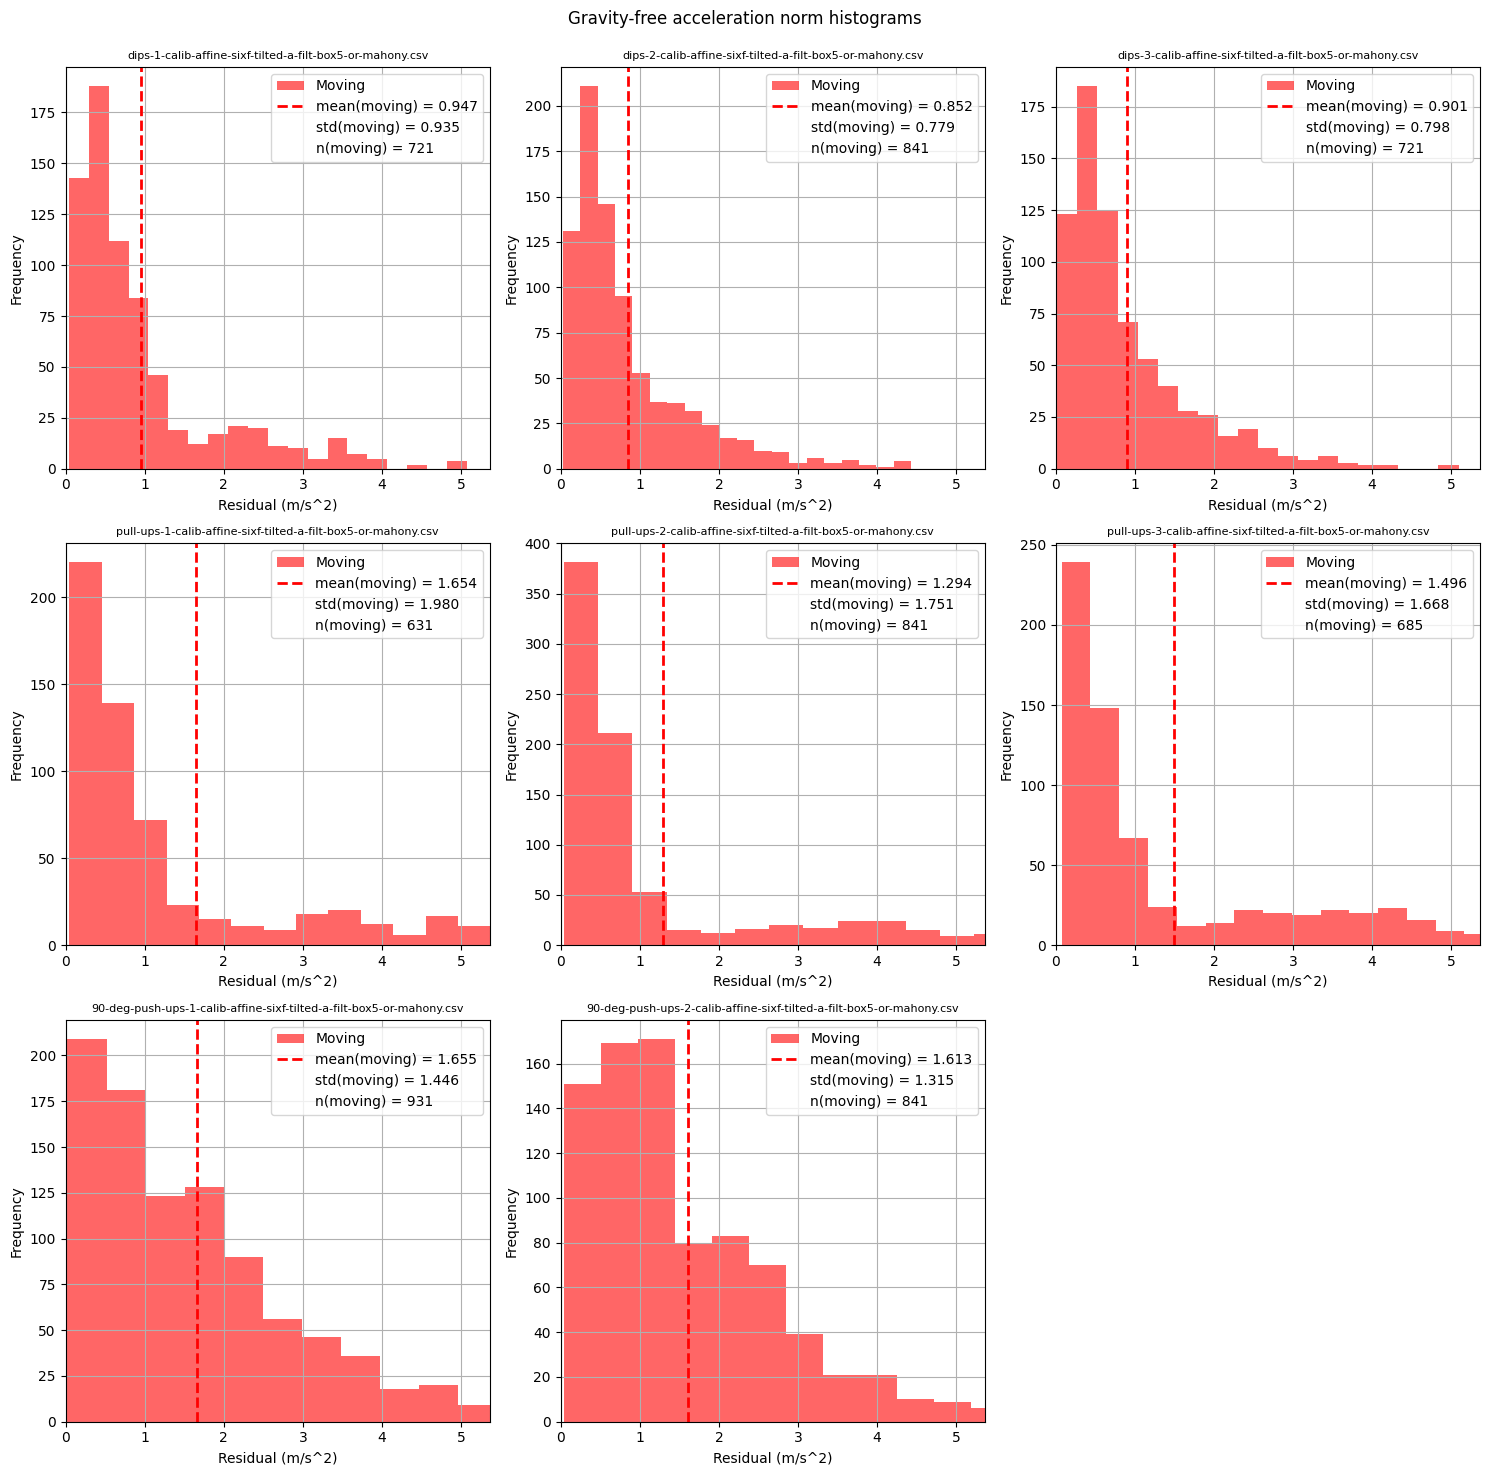

In [20]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(
        gridSearchDirectories[DIRECTORY_IDX], realExerciseCaptures
    )
)

### Time series of norms

For captures with high stationary means relative to the others, inspect the time series graph of raw and gravity-free acceleration norms closer. Also compare against angle graphs from the complementary filter notebook. 

General properties:

* When the raw signal is close to $g$, the other one should be close to 0. 
* The norm is strictly non-negative, so when the raw signal exhibits a valley, the gravity-free signal should exhibit a peak. 
* Exercise repetitions should be possible to identify in the gravity-free signal. 
* Amplitudes need not to be the same. 
* Both signals should not have big phase differences. 

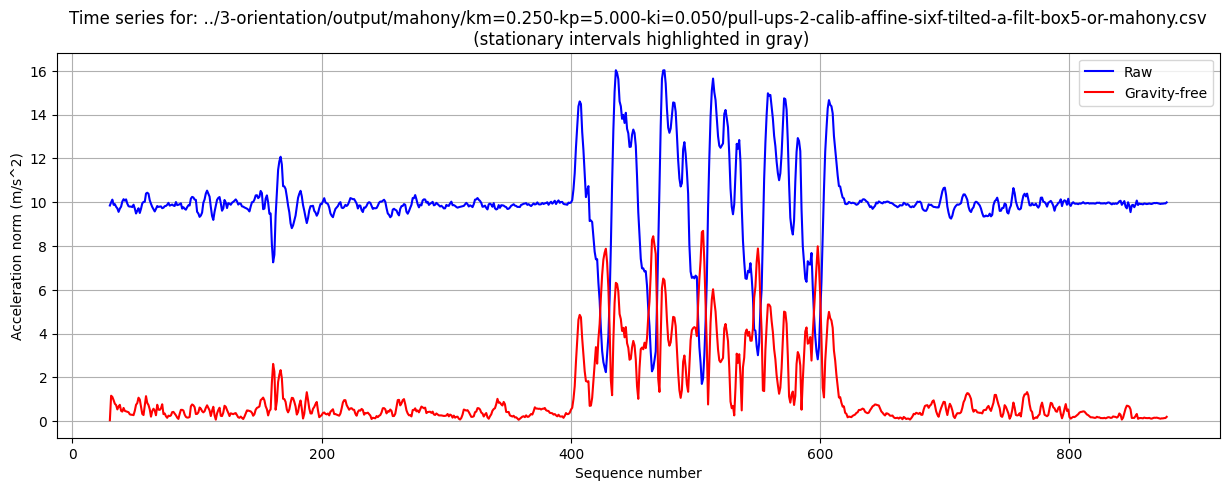

In [21]:
CAPTURE_IDX = 4
chosenCapture = mergeDirectoryWithCaptures(
    gridSearchDirectories[DIRECTORY_IDX], realExerciseCaptures
)[CAPTURE_IDX]

readValues = reader.read(chosenCapture)
seq = readValues[0]
fB = readValues[1]
wB = readValues[2]
eulerAngles = readValues[3]

aB = subtractGravityEuler(fB, eulerAngles)
fBNorm = np.linalg.norm(fB, axis=1)
gravityFreeAccelNorm = np.linalg.norm(aB, axis=1)  # type: ignore
stationaryIntervals = stationaryDetector.findStationaryIntervals(seq, fB, wB)

fig, axis = plt.subplots(figsize=(15, 5))
axis.plot(seq, fBNorm, label="Raw", color="blue")
axis.plot(seq, gravityFreeAccelNorm, label="Gravity-free", color="red")
axis.set_title(
    f"Time series for: {chosenCapture}\n (stationary intervals highlighted in gray)"
)
axis.set_xlabel("Sequence number")
axis.set_ylabel("Acceleration norm (m/s^2)")
for lower, upper in stationaryIntervals:
    axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)
axis.legend()
axis.grid()
plt.show()

### Scatter plots

Points should follow a functional relationship, either linear or non-linear, instead of being a random cloud of points. Both Pearson and Spearman correlation coefficients are considered. These should be as close to 1 as possible.

Sources:
* https://www.youtube.com/watch?v=k7IctLRiZmo
* https://www.youtube.com/watch?v=XV_W1w4Nwoc
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rankdata.html
* https://en.wikipedia.org/wiki/Ranking
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html#scipy.stats.spearmanr

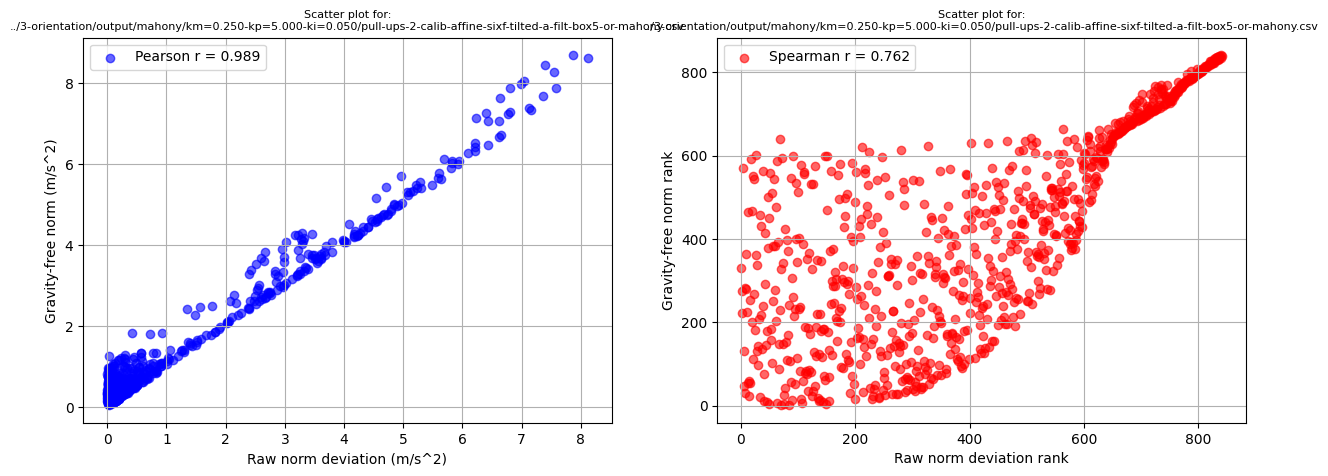

In [22]:
stationaryMask = stationaryDetector.areStationarySamples(fB, wB)
fBDeviation = np.abs(fBNorm - stationaryDetector.accelCenter)
pearsonR = stats.pearsonr(fBDeviation, gravityFreeAccelNorm)[0]

rawAccelNormRanks = stats.rankdata(fBDeviation, method="average")
gravityFreeAccelNormRanks = stats.rankdata(gravityFreeAccelNorm, method="average")
spearmanR = stats.spearmanr(fBDeviation, gravityFreeAccelNorm)[0]

fig, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].set_title(f"Scatter plot for:\n{chosenCapture}", fontsize=8)
axis[0].scatter(
    fBDeviation,
    gravityFreeAccelNorm,
    c="blue",
    alpha=0.6,
)
axis[0].scatter([], [], c="blue", alpha=0.6, label=f"Pearson r = {pearsonR:.3f}")
axis[0].set_xlabel("Raw norm deviation (m/s^2)")
axis[0].set_ylabel("Gravity-free norm (m/s^2)")
axis[0].legend()
axis[0].grid()

axis[1].set_title(f"Scatter plot for:\n{chosenCapture}", fontsize=8)
axis[1].scatter(
    rawAccelNormRanks,
    gravityFreeAccelNormRanks,
    c="red",
    alpha=0.6,
)
axis[1].scatter([], [], c="red", alpha=0.6, label=f"Spearman r = {spearmanR:.3f}")
axis[1].set_xlabel("Raw norm deviation rank")
axis[1].set_ylabel("Gravity-free norm rank")
axis[1].legend()
axis[1].grid()

plt.show()

### Cross correlation

The time displacement or lag of the complementary filter + rotation matrix with respect to the raw signal can be estimated by computing the cross correlation between both signals. Ideally, the lag should be close to 0 but positive. Notice that a negative lag would mean that the gravity-free signal is ahead of the raw signal, which is not physically possible. The lag is given by the index of the maximum value of the cross correlation function. The peak should have relatively high magnitude even after normalization. 

Sources:
- [The scientist and engineer's guide to DSP, Chapter 7](../../docs/misc/The%20Scientist%20and%20Engineers%20Guide%20to%20Digital%20signal%20processing%20-%20Steven%20W.%20Smith.pdf)
- https://www.youtube.com/watch?v=L6YJqhbsuFY
- https://www.youtube.com/watch?v=MQm6ZP1F6ms
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlation_lags.html#scipy.signal.correlation_lags


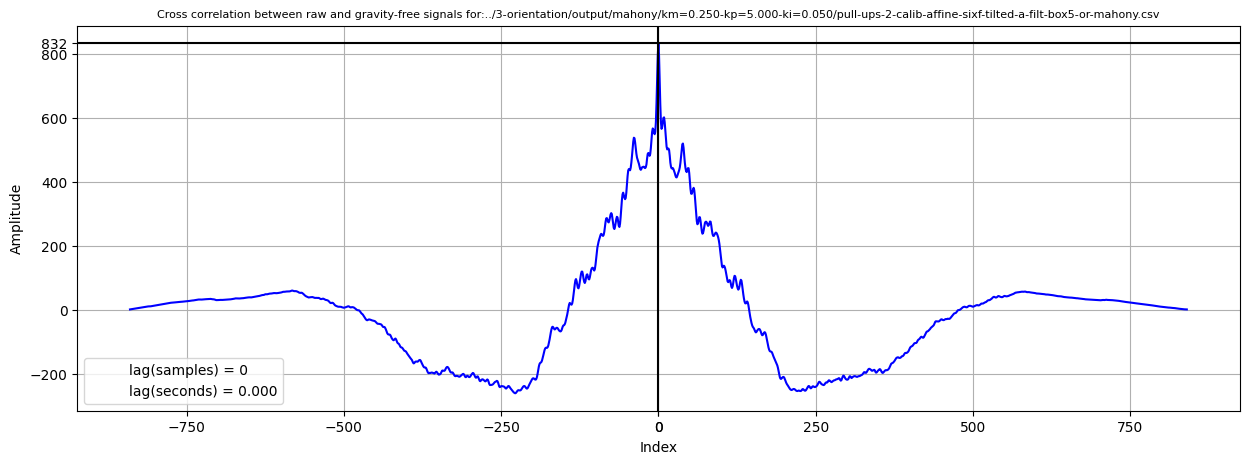

In [23]:
normalizedRawAccelDeviation = fBDeviation - np.mean(fBDeviation)
normalizedRawAccelDeviation /= np.std(normalizedRawAccelDeviation)
normalizedGravityFreeAccelNorm = gravityFreeAccelNorm - np.mean(gravityFreeAccelNorm)
normalizedGravityFreeAccelNorm /= np.std(normalizedGravityFreeAccelNorm)
corr = signal.correlate(normalizedRawAccelDeviation, normalizedGravityFreeAccelNorm)
lags = signal.correlation_lags(
    len(normalizedRawAccelDeviation), len(normalizedGravityFreeAccelNorm)
)
maxCorr = np.max(corr)
lagSamples = lags[np.argmax(corr)]
lagSeconds = lagSamples / SAMPLING_FREQUENCY

fig, axis = plt.subplots(figsize=(15, 5))
axis.set_title(
    f"Cross correlation between raw and gravity-free signals for:{chosenCapture}",
    fontsize=8,
)
axis.plot(lags, corr, color="blue")

axis.axvline(
    lagSamples,
    color="black",
)
axis.axhline(
    maxCorr,
    color="black",
)
xTicks = list(axis.get_xticks())
xTicks.append(lagSamples)
axis.set_xticks(sorted(xTicks))
yTicks = list(axis.get_yticks())
yTicks.append(maxCorr)
axis.set_yticks(sorted(yTicks))

axis.plot([], [], linestyle="", label=f"lag(samples) = {lagSamples}")
axis.plot([], [], linestyle="", label=f"lag(seconds) = {lagSeconds:.3f}")

axis.set_xlabel("Index")
axis.set_ylabel("Amplitude")
axis.legend()
axis.grid()
plt.show()

## Conclusion and export results

Key performance metrics:

| Filter | Sensor | Parameters (optimal) | Gravity-free stationary mean ($m/s^2$) | $\bar{r}$ | $r_{\min}$ | $\bar{\rho}$ | $\rho_{\min}$ | $\bar{lag}$ (samples) |
|---|---|---|---|---|---|---|---|---|
| Complementary | MPU6050 | $(\alpha_{\mathrm{stationary}}, \alpha_{\mathrm{moving}}) = (0.75, 0.95)$ | $\sim 0.22$ | $\sim 0.95$ | $\sim 0.92$ | $\sim 0.79$ | $\sim 0.73$ | 0 |
| Mahony | MPU6050 | $(K_M, K_P, K_I) = (0.25, 5, 0.05)$ | $\sim 0.16$ | $\sim 0.94$ | $\sim 0.89$ | $\sim 0.80$ | $\sim 0.76$ | 0 |

Comments:
* Visual inspection of graphs look fine for both filters and all exercise captures.  
* Fine-tuning of Mahony filter's parameters don't seem to yield big improvements. 
* Modest improvements of the Mahony with respect to the complementary filter strongly suggest diminishing returns for more complex filtering approaches. A better IMU sensor should be considered.
* On both cases the remaining error is not good enough for accurate free-running velocity estimation.
* The Mahony filter is still considered better since its orientation representation avoids gimbal lock and it may be actually cheaper computationally than the modified complementary filter, which makes extensive use of trigonometric functions.
* A realistic stationary detection (windowed, small tolerance band) fails on real exercise captures as they really didn't have strict stationary periods.

In [24]:
FINAL_DIRECTORY_IDX = DIRECTORY_IDX
for capture in mergeDirectoryWithCaptures(
    gridSearchDirectories[FINAL_DIRECTORY_IDX],
    [*stationaryCaptures, *simpleRotationsCaptures, *realExerciseCaptures],
):
    readValues = reader.read(capture)
    seq = readValues[0]
    fB = readValues[1]
    wB = readValues[2]
    angles = readValues[3]
    aB = subtractGravityEuler(fB, angles)
    oldFilename = capture.split("/")[-1].split(".")[0]
    if len(readValues) > 4:
        s = readValues[4]
        v = readValues[5]
        writer.write(
            outputFile=f"./output/{oldFilename}-g-free.csv",
            seq=seq,
            a=aB,
            w=wB,
            angle=angles,
            q=np.hstack((s[:, np.newaxis], v)),
        )
    else:
        writer.write(
            outputFile=f"./output/{oldFilename}-g-free.csv",
            seq=seq,
            a=aB,
            w=wB,
            angle=angles,
        )